# M4 Final Exam 2 (Assignment)
Binary Classification Using ML Approach

 Business Context:
A retail company operates 2000 stores across Europe. Each store is observed for one financial quarter. Based on marketing investments and customer engagement, management is interested in predicting whether a store achieves high sales performance during the quarter.

Dataset Description
Each row represents one store for one quarter.

Predictor Variables:
1. TV_Ad_Spend_EUR - Quarterly TV advertising spend allocated to the store (EUR)
2. Digital_Ad_Spend_EUR - Quarterly digital marketing spend (EUR)
3. Print_Ad_Spend_EUR - Quarterly print media spend (EUR)
4. Price_Discount_Percent - Average discount offered during the quarter (%)
5. Store_Visits - Number of customer visits during the quarter

Target Variable:
- TargetSales_Flag - Binary indicator (1 = High sales achieved, 0 = Otherwise)

Models to be Used
Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
Tasks
1. Load the dataset and perform basic exploratory analysis.
2. Split the data into training (70%) and testing (30%) sets using a fixed random seed.
3. For each of the following models : Logistic Regression, Decision Tree, and Random Forest - build the model using the training data, generate predicted probabilities on the test data, and compute the Test ROC-AUC.
4. Compare the AUC values and identify the best-performing model.
5. Perform K-fold cross validation for the best model
Students should discuss which model performs best in terms of AUC, and whether increased complexity leads to meaningful performance gains.

In [28]:
import pandas as pd

df = pd.read_csv("M4 ASSIGNMENT 2 DATA.csv")
df.head()

,TV_Ad_Spend_EUR,Digital_Ad_Spend_EUR,Print_Ad_Spend_EUR,Price_Discount_Percent,Store_Visits,TargetSales_Flag
0,284658.2905,135559.55260,36004.4834,1.074174,5231.575136,0
1,128732.9473,127010.21450,193912.7247,7.017386,6870.648290,0
2,106203.5524,25459.82771,123787.8731,11.895431,6695.299765,0
3,229499.6123,266945.58440,36932.1245,4.575947,8858.916578,1
4,293398.2085,207796.83120,161809.8982,19.390237,3244.275457,1


In [29]:
df.describe()

,TV_Ad_Spend_EUR,Digital_Ad_Spend_EUR,Print_Ad_Spend_EUR,Price_Discount_Percent,Store_Visits,TargetSales_Flag
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,209903.258663,156437.633972,102273.102376,12.540002,7925.819489,0.500000
std,111203.463390,82037.704518,56136.480730,7.126397,4034.982511,0.500125
min,20031.117290,15019.333920,5024.318706,0.007437,1003.795804,0.000000
25%,112399.816850,85997.668905,51138.601593,6.364006,4213.490139,0.000000
50%,208855.985550,158556.688350,105427.587550,12.582149,7995.151829,0.500000
75%,305275.359950,226669.020925,149950.585600,18.506343,11454.763243,1.000000
max,399864.815300,299818.338800,199978.562600,24.971284,14991.251820,1.000000


In [30]:
df.isnull().sum()

TV_Ad_Spend_EUR           0
Digital_Ad_Spend_EUR      0
Print_Ad_Spend_EUR        0
Price_Discount_Percent    0
Store_Visits              0
TargetSales_Flag          0
dtype: int64

In [31]:
df['TargetSales_Flag'].value_counts()

TargetSales_Flag
0    1000
1    1000
Name: count, dtype: int64

In [32]:
corr_matrix = df.corr()
print("Correlation Matrix:")
corr_matrix

Correlation Matrix:


,TV_Ad_Spend_EUR,Digital_Ad_Spend_EUR,Print_Ad_Spend_EUR,Price_Discount_Percent,Store_Visits,TargetSales_Flag
TV_Ad_Spend_EUR,1.000000,0.035231,0.031190,-0.011924,-0.034418,0.290044
Digital_Ad_Spend_EUR,0.035231,1.000000,-0.014443,-0.028326,0.006587,0.309175
Print_Ad_Spend_EUR,0.031190,-0.014443,1.000000,-0.000172,-0.032883,0.096137
Price_Discount_Percent,-0.011924,-0.028326,-0.000172,1.000000,-0.013550,0.390159
Store_Visits,-0.034418,0.006587,-0.032883,-0.013550,1.000000,0.410641
TargetSales_Flag,0.290044,0.309175,0.096137,0.390159,0.410641,1.000000


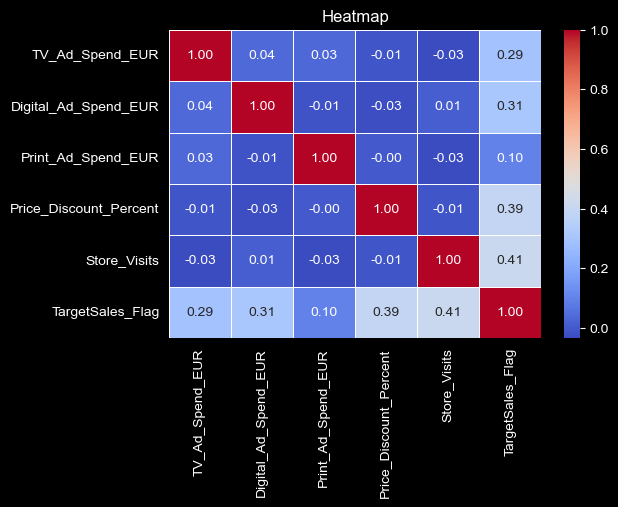

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Heatmap")
plt.show()

The target variable is perfectly balanced, with the same number of high-sales and non-high-sales stores. The correlation matrix also suggests that `Store_Visits`, `Price_Discount_Percent`, and `Digital_Ad_Spend_EUR` have the strongest positive association with `TargetSales_Flag`, while multicollinearity among predictors remains limited.

# Train-Test Split (70/30)

In [34]:
from sklearn.model_selection import train_test_split

X = df[['TV_Ad_Spend_EUR',
        'Digital_Ad_Spend_EUR',
        'Print_Ad_Spend_EUR',
        'Price_Discount_Percent',
        'Store_Visits']]

y = df['TargetSales_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

## Logistic Regression

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_proba = logistic_model.predict_proba(X_test)[:, 1]
logistic_auc = roc_auc_score(y_test, logistic_proba)

print("Logistic Regression AUC:", logistic_auc)

Logistic Regression AUC: 0.9381777777777778


Logistic Regression delivers strong discrimination performance and provides a solid baseline for binary classification. Its high AUC suggests that the relationship between the predictors and the target is captured well even with a relatively simple linear decision boundary.

## Decision Tree Classifier

In [36]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=20
)

decision_tree_model.fit(X_train, y_train)

decision_tree_proba = decision_tree_model.predict_proba(X_test)[:, 1]
decision_tree_auc = roc_auc_score(y_test, decision_tree_proba)

print("Decision Tree AUC:", decision_tree_auc)

Decision Tree AUC: 0.8691444444444445


The Decision Tree captures non-linear patterns, but its test AUC is lower than Logistic Regression. This indicates that the additional flexibility of the tree does not translate into better ranking performance for this dataset.

## Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=10,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_proba = random_forest_model.predict_proba(X_test)[:, 1]
random_forest_auc = roc_auc_score(y_test, random_forest_proba)

print("Random Forest AUC:", random_forest_auc)

Random Forest AUC: 0.9225666666666666


Random Forest improves over a single tree by reducing variance through ensembling. However, in this case its AUC remains slightly below Logistic Regression, which suggests that the underlying class separation is already well represented by a simpler model.

## Model Comparison

In [38]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Test ROC-AUC': [logistic_auc, decision_tree_auc, random_forest_auc]
}).sort_values(by='Test ROC-AUC', ascending=False)

model_comparison

,Model,Test ROC-AUC
0,Logistic Regression,0.938178
2,Random Forest,0.922567
1,Decision Tree,0.869144


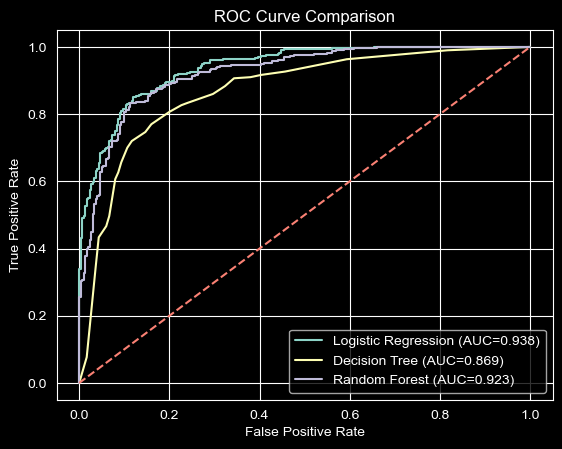

In [39]:
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_proba)
decision_tree_fpr, decision_tree_tpr, _ = roc_curve(y_test, decision_tree_proba)
random_forest_fpr, random_forest_tpr, _ = roc_curve(y_test, random_forest_proba)

plt.figure()
plt.plot(logistic_fpr, logistic_tpr, label=f"Logistic Regression (AUC={logistic_auc:.3f})")
plt.plot(decision_tree_fpr, decision_tree_tpr, label=f"Decision Tree (AUC={decision_tree_auc:.3f})")
plt.plot(random_forest_fpr, random_forest_tpr, label=f"Random Forest (AUC={random_forest_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

The ROC-AUC comparison shows that Logistic Regression is the best-performing model on the test set. Although Random Forest is more sophisticated than a linear classifier, its gain is not sufficient to surpass the simpler model, and the Decision Tree performs worst among the three approaches.

## Cross Validation

In [40]:
from sklearn.model_selection import cross_val_score

logistic_cv = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

decision_tree_cv = cross_val_score(
    decision_tree_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

random_forest_cv = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

cv_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Mean CV AUC': [logistic_cv.mean(), decision_tree_cv.mean(), random_forest_cv.mean()],
    'Std CV AUC': [logistic_cv.std(), decision_tree_cv.std(), random_forest_cv.std()]
}).sort_values(by='Mean CV AUC', ascending=False)

cv_summary

,Model,Mean CV AUC,Std CV AUC
0,Logistic Regression,0.937190,0.011020
2,Random Forest,0.924910,0.009639
1,Decision Tree,0.863293,0.012769


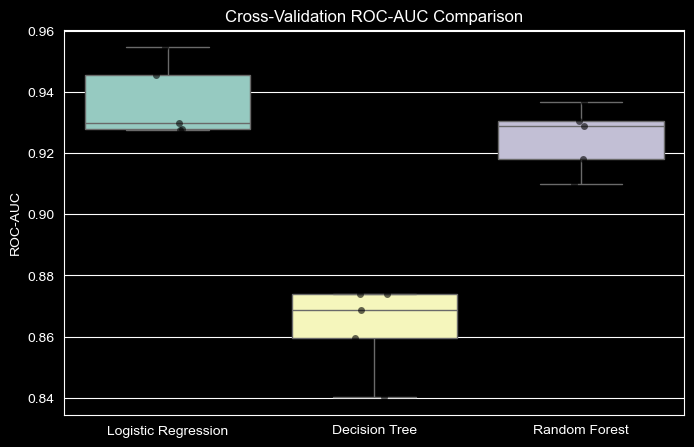

In [41]:
cv_comparison = pd.DataFrame({
    'Logistic Regression': logistic_cv,
    'Decision Tree': decision_tree_cv,
    'Random Forest': random_forest_cv
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_comparison)
sns.stripplot(data=cv_comparison, color='black', alpha=0.6)
plt.ylabel('ROC-AUC')
plt.title('Cross-Validation ROC-AUC Comparison')
plt.show()

The cross-validation comparison confirms that Logistic Regression has both the highest average ROC-AUC and a stable distribution across folds. Random Forest is also consistent, but it does not outperform the simpler model, while the Decision Tree shows clearly weaker classification performance.

## Final Deduction

Logistic Regression should be preferred for this task because it achieved the highest ROC-AUC while remaining the most interpretable and parsimonious model. The results indicate that the dataset contains a strong and mostly well-structured signal, so a more complex classifier does not provide a meaningful advantage over the simpler binary classification approach.